# Customer Campaign Response and Supporting Segmentation
## Revised capstone notebook

**Primary task:** binary prediction of acceptance of the recorded last campaign. **Supporting task:** exploratory customer segmentation.

This notebook covers rubric Steps 1–5 and prepares reproducible local artifacts for Step 7. It revises the original analysis through fold-specific preprocessing, group-aware nested validation, comparable tuning, validation-only targeting policies, complete fairness audits and saved inference bundles. Technical and business presentations are separate deliverables.

**Dataset:** [Customer Personality Analysis on Kaggle](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data), credited by the data card to Dr. Omar Romero-Hernandez. The snapshot contains historical customer data. Country, currency and exact campaign timing are not established here.

**Evaluation disclosure:** the original notebook already examined this dataset and its holdout. The revised procedure uses nested grouped cross-validation for a more disciplined internal estimate. No partition is represented as newly collected external data. New-campaign or external validation remains necessary.

**How to use:** extract the complete project and run `python execute_notebook.py` from its root after installing `requirements.txt`. Keep `src/`, `data/` and the notebook together. All tables and findings below are generated from the same run.

## Step 1 Problem understanding and measurable objectives

The business scenario is a marketing team with limited outreach capacity. Historical labels identify customers who accepted the last recorded campaign. Predictive ranking could concentrate outreach on likely responders, while a fairness audit checks whether the targeting policy distributes opportunities unevenly.

| Item | Definition |
|---|---|
| Prediction target | `Response`: 1 accepted the last campaign, 0 did not |
| Model-selection metric | Mean inner-validation ROC-AUC; fixed before evaluation |
| Additional model metrics | Average precision (AP), F1, responder recall, precision, top-20% precision/capture |
| Outreach policy | Validation-fitted F1 threshold, then a predefined children-at-home disparity adjustment |
| Fairness objective | Smallest adjustment reaching selection-rate ratio 0.80 on policy-validation data; this is a project assumption, not a guarantee of fairness |
| Comparison budget | Fixed top 20% by model score, evaluated as an alternative policy |
| Business measures | Contacts, response concentration, cost per observed responder, and an illustrative value proxy |
| Illustrative economics | Value 11 per recorded responder and contact cost 3, in unspecified units; unverified contribution margin |
| Provisional technical targets | Outer-fold mean AUC ≥0.80; pooled top-20% response rate ≥2× overall prevalence; positive illustrative policy value |
| Adoption gate | Review uncertainty, all-group disparities, privacy and feature timing; validate prospectively before use |

The acceptance targets are proposed for this revision, not stakeholder-approved commitments. The project predicts historical response, not causal campaign uplift. A controlled experiment would be needed to establish incremental business value.

## Reproducibility and configuration

The input file is tab-separated despite its `.csv` extension. Fixed cleaning rules precede splitting. No income imputation, percentile clipping, supervised feature selection or classifier scaling is fitted on evaluation data.

Five outer folds evaluate the complete selection procedure. Inside each outer development fold, a grouped 80/20 split separates model fitting from policy validation. Four candidate algorithms each receive eight sampled configurations with three inner grouped folds. The outer fold is used only after the model and policy have been frozen.

In [1]:
from pathlib import Path
import os, sys, json, hashlib, platform
ROOT = Path.cwd()
if not (ROOT / "data/raw/marketing_campaign.csv").exists():
    ROOT = ROOT.parent
assert (ROOT / "data/raw/marketing_campaign.csv").exists(), "Open this notebook from the extracted project."
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".runtime/matplotlib"))
for folder in ["data/processed", "models", "reports/figures", "reports/tables"]:
    (ROOT / folder).mkdir(parents=True, exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
from src.pipeline import (clean_data, CustomerFeatures, run_nested, fit_final_candidate, predict_bundle,
                          write_json, json_safe, SPEND, PURCHASES, REF_DATE)
from src.fairness import make_sensitive, apply_policy, evaluate_predictions, audit_fairness
RANDOM_STATE = 42
CONFIG = {"outer_folds": 5, "inner_folds": 3, "n_iter": 8, "seed": RANDOM_STATE}
write_json(ROOT / "run_config.json", CONFIG)
pd.set_option("display.max_columns", 18)
pd.set_option("display.max_rows", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
def save_plot(name):
    plt.tight_layout()
    plt.savefig(ROOT / "reports/figures" / (name + ".png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
versions = {name: __import__(name).__version__ for name in ["numpy", "pandas", "sklearn", "scipy", "xgboost", "shap"]}
print("Python", platform.python_version(), "| package versions", versions)
print("Reproducible configuration:", CONFIG)

Python 3.9.6 | package versions {'numpy': '1.26.4', 'pandas': '2.3.3', 'sklearn': '1.6.1', 'scipy': '1.13.1', 'xgboost': '2.1.4', 'shap': '0.49.1'}
Reproducible configuration: {'outer_folds': 5, 'inner_folds': 3, 'n_iter': 8, 'seed': 42}


## Step 2 Data collection and understanding

The source data card and local dictionary distinguish observed values from allowed-domain assumptions. Income and spending have unspecified currency; spending totals refer to two years, but the purchase-count observation windows are not verified. Those limitations matter when engineering ratios and interpreting business value.

In [2]:
raw_path = ROOT / "data/raw/marketing_campaign.csv"
df_raw = pd.read_csv(raw_path, sep="\t")
assert df_raw.shape[1] == 29
print("Raw shape:", df_raw.shape)
print("Dataset SHA256:", hashlib.sha256(raw_path.read_bytes()).hexdigest())
overview = pd.DataFrame({"type": df_raw.dtypes.astype(str), "missing": df_raw.isna().sum(),
                         "missing_pct": 100 * df_raw.isna().mean(), "unique": df_raw.nunique()})
display(overview.round(2))
display(df_raw.head(3))
print("Exact duplicates:", df_raw.duplicated().sum())
print("Matching profiles ignoring ID and Response:", df_raw.drop(columns=["ID", "Response"]).duplicated().sum())
display(df_raw.describe().T.round(2))

Raw shape: (2240, 29)
Dataset SHA256: cd0affa36b1b981e80ba0e27767e9b3ab723f7a3dba948f722af81abc6b990ea


,type,missing,missing_pct,unique
ID,int64,0,0.00,2240
Year_Birth,int64,0,0.00,59
Education,object,0,0.00,5
Marital_Status,object,0,0.00,8
Income,float64,24,1.07,1974
Kidhome,int64,0,0.00,3
Teenhome,int64,0,0.00,3
Dt_Customer,object,0,0.00,663
Recency,int64,0,0.00,100
MntWines,int64,0,0.00,776


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,...,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,...,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,...,0,0,0,0,0,0,3,11,0


Exact duplicates: 0
Matching profiles ignoring ID and Response: 201


,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.16,3246.66,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.81,11.98,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.25,25173.08,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.44,0.54,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.51,0.54,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0


In [3]:
dictionary = pd.read_csv(ROOT / "data/data_dictionary.csv")
assert len(dictionary) == 29
# The Markdown version is also readable without running this notebook.
display(dictionary)
display(Markdown("Full definitions and source caveats: [data dictionary](../data/DATA_DICTIONARY.md)."))

,variable,type,meaning,unit,allowed_values,observed_range_or_values,missing_count,model_role,caveats
0,ID,integer identifier,Customer record identifier,identifier,Unique integer within the source file,0 to 11191,0,identifier only,Distinct IDs are retained. Identical measured ...
1,Year_Birth,integer,Birth year,calendar year,Plausible birth year for the historical data p...,1893 to 1996,0,candidate predictor through derived age,Eligibility requires 1920 to 1996 inclusive. T...
2,Education,categorical string,Education category,category,Basic; 2n Cycle; Graduation; Master; PhD,2n Cycle; Basic; Graduation; Master; PhD,0,candidate predictor and audit attribute,Categories are not equally spaced measurements...
3,Marital_Status,categorical string,Household relationship category,category,Single; Together; Married; Divorced; Widow; Al...,Absurd; Alone; Divorced; Married; Single; Toge...,0,candidate predictor and audit attribute,Alone is mapped to Single. All four records la...
4,Income,numeric with missing values,Annual household income,unspecified currency per year,Positive numeric value below 600000 or missing...,1730 to 666666,24,candidate predictor and audit attribute,All 24 missing values are retained. Eligibilit...
5,Kidhome,integer count,Children recorded at home,people,0; 1; 2 observed,0; 1; 2,0,candidate predictor through household features,Age boundary for this field is not supplied. C...
6,Teenhome,integer count,Teenagers recorded at home,people,0; 1; 2 observed,0; 1; 2,0,candidate predictor through household features,Exact age boundaries are unavailable. Treat as...
7,Dt_Customer,date stored as text,Company enrolment date,"day-month-year, DD-MM-YYYY",Valid date in the source format,2012-07-30 to 2014-06-29,0,candidate predictor through historical tenure,Not a campaign timestamp. Historical tenure is...
8,Recency,integer count,Time since the latest purchase,days,Nonnegative integer,0 to 99,0,candidate predictor,The source does not supply a dated measurement...
9,MntWines,integer amount,Wine spending,unspecified currency over the previous two years,Nonnegative amount,0 to 1493,0,candidate predictor,The two-year window is undated and may overlap...


Full definitions and source caveats: [data dictionary](../data/DATA_DICTIONARY.md).

## Step 3 Cleaning and applied exploratory analysis

Cleaning uses explicitly documented historical eligibility assumptions: birth years 1920–1996 and positive income below 600,000 when present. The three very old birth years and income 666,666 are treated as suspicious and excluded; this is an analytical assumption rather than proof that the records are incorrect. Missing income stays missing until each training pipeline fits its median.

`Alone` is normalised to `Single`. Rare `Absurd`/`YOLO` marital labels become `Unknown`; their customers remain. Distinct customer IDs with matching profiles remain too, because equal profiles do not prove the same person. A profile key excludes both ID and Response and forces all matching profiles into the same partition, including conflicting responses. Fixed filtering restricts the population to which conclusions apply.

In [4]:
df, groups, cleaning_log = clean_data(df_raw)
display(cleaning_log)
print(f"Eligible customers: {len(df):,}; distinct profile groups: {len(np.unique(groups)):,}")
print(f"Income missing before fold-local imputation: {df.Income.isna().sum()}")
print("Retained rare marital labels:", df.Marital_Status.value_counts().to_dict())
df.assign(Profile_Group=groups).to_csv(ROOT / "data/processed/customers_eligible.csv", index=False)
cleaning_log.to_csv(ROOT / "reports/tables/cleaning_log.csv", index=False)
eda = CustomerFeatures().fit_transform(df.drop(columns="Response"))
assert not np.isinf(eda.to_numpy()).any()
print("Engineered feature count before fold-specific variance filtering/selection:", eda.shape[1])

,step,rows_remaining
0,Raw rows,2240
1,Remove exact repeated records,2240
2,Eligibility: birth year 1920 to 1996,2237
3,Eligibility: positive income below 600000 or m...,2236
4,Retain distinct customer IDs and create profil...,2236


Eligible customers: 2,236; distinct profile groups: 2,034
Income missing before fold-local imputation: 24
Retained rare marital labels: {'Married': 864, 'Together': 578, 'Single': 482, 'Divorced': 231, 'Widow': 77, 'Unknown': 4}
Engineered feature count before fold-specific variance filtering/selection: 43


### Feature engineering decisions

| Feature family | Reason and limitation |
|---|---|
| Age and tenure | Fixed historical reference 2014-06-30 makes the calculation reproducible; it is not a verified campaign date |
| Total spending and channel purchases | Summaries of observed commercial activity |
| Product and channel shares | Relative preferences within the same source variable family |
| Spend per recorded purchase and spend-to-income | Labelled proxies because observation windows differ or are unknown |
| Zero-purchase and missing-income flags | Preserve an indication of unavailable or inconsistent inputs |
| Children at home and household-size proxy | Household context, subject to explicit fairness audit; not proof of parenthood |
| Previous accepted campaigns | Candidate historical behaviour, assuming campaigns 1–5 precede the last campaign; timing remains unverified |
| Education indicators | Fixed one-hot categories avoid imposing an unsupported ordinal spacing |

The classifier pipeline learns medians and selected numeric caps within each fit. A variance filter removes constant predictors, and an ANOVA filter selects 60%, 80% or 100% of the remaining predictors through inner validation. Its univariate ranking may miss interactions; 100% retention is therefore a candidate. Scaling stays inside the pipeline. The tree models do not require scaling, but the monotone scaling allows a common audited feature path.

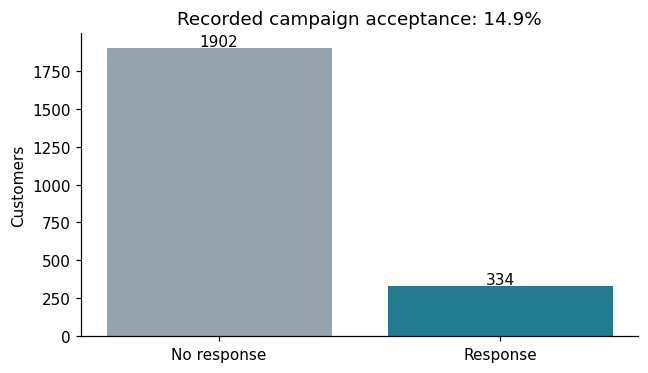

**Observed imbalance:** 334 of 2,236 customers responded (14.9%). An always-no classifier obtains 85.1% accuracy while capturing no responders. This motivates ranking, precision and recall metrics.

In [5]:
prevalence = df.Response.mean()
fig, ax = plt.subplots(figsize=(6, 3.5))
counts = df.Response.value_counts().sort_index()
ax.bar(["No response", "Response"], counts.values, color=["#96a2ad", "#247b91"])
ax.set_ylabel("Customers"); ax.set_title(f"Recorded campaign acceptance: {prevalence:.1%}")
for i,v in enumerate(counts): ax.text(i,v+10,str(v),ha="center")
save_plot("01_response_balance")
display(Markdown(f"**Observed imbalance:** {int(df.Response.sum()):,} of {len(df):,} customers responded ({prevalence:.1%}). An always-no classifier obtains {(1-prevalence):.1%} accuracy while capturing no responders. This motivates ranking, precision and recall metrics."))

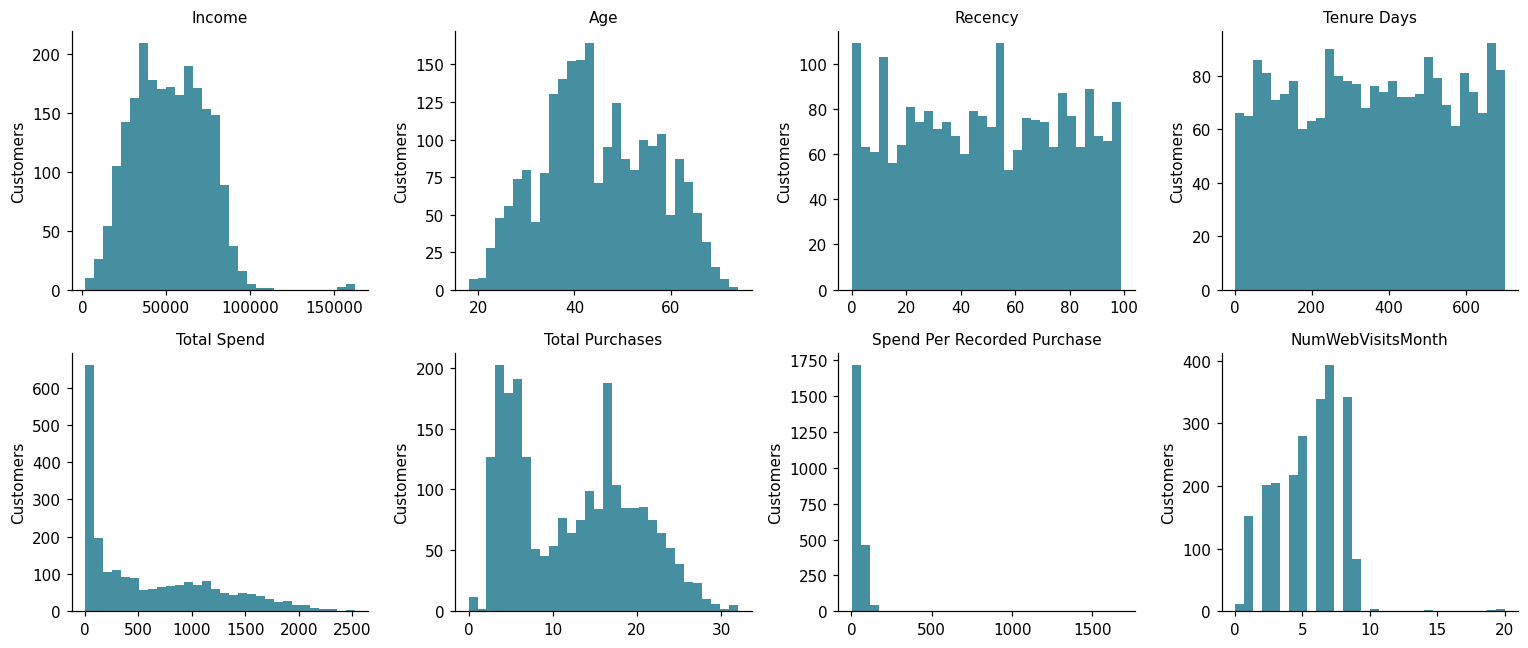

,count,mean,std,min,25%,50%,75%,max
Income,2212.0,51958.81,21527.28,1730.00,35233.50,51371.00,68487.00,162397.0
Age,2236.0,45.10,11.70,18.00,37.00,44.00,55.00,74.0
Recency,2236.0,49.12,28.96,0.00,24.00,49.00,74.00,99.0
Tenure_Days,2236.0,354.77,202.18,1.00,181.75,357.00,530.00,700.0
Total_Spend,2236.0,605.99,601.87,5.00,69.00,396.50,1045.50,2525.0
Total_Purchases,2236.0,12.55,7.21,0.00,6.00,12.00,18.00,32.0
Spend_Per_Recorded_Purchase,2230.0,38.20,45.92,2.67,13.00,29.84,49.17,1679.0
NumWebVisitsMonth,2236.0,5.32,2.43,0.00,3.00,6.00,7.00,20.0


**Interpretation:** income and spending include long upper tails. Ratios based on small recorded purchase counts can be extreme. Training-only caps limit their influence; zero denominators stay missing and are imputed inside the training pipeline. These plots describe the reused snapshot and are not independent validation evidence.

In [6]:
columns = ["Income", "Age", "Recency", "Tenure_Days", "Total_Spend", "Total_Purchases", "Spend_Per_Recorded_Purchase", "NumWebVisitsMonth"]
fig, axes = plt.subplots(2,4,figsize=(14,6))
for ax,col in zip(axes.ravel(),columns):
    ax.hist(eda[col].dropna(),bins=30,color="#247b91",alpha=.85)
    ax.set_title(col.replace("_", " "),fontsize=10)
    ax.set_ylabel("Customers")
save_plot("02_distributions")
display(eda[columns].describe().T.round(2))
display(Markdown("**Interpretation:** income and spending include long upper tails. Ratios based on small recorded purchase counts can be extreme. Training-only caps limit their influence; zero denominators stay missing and are imputed inside the training pipeline. These plots describe the reused snapshot and are not independent validation evidence."))

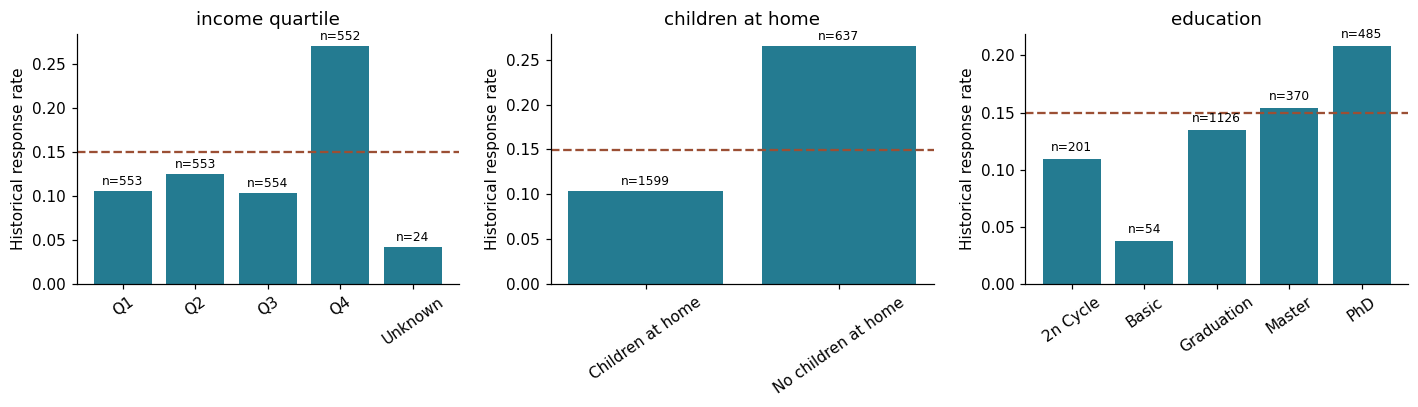

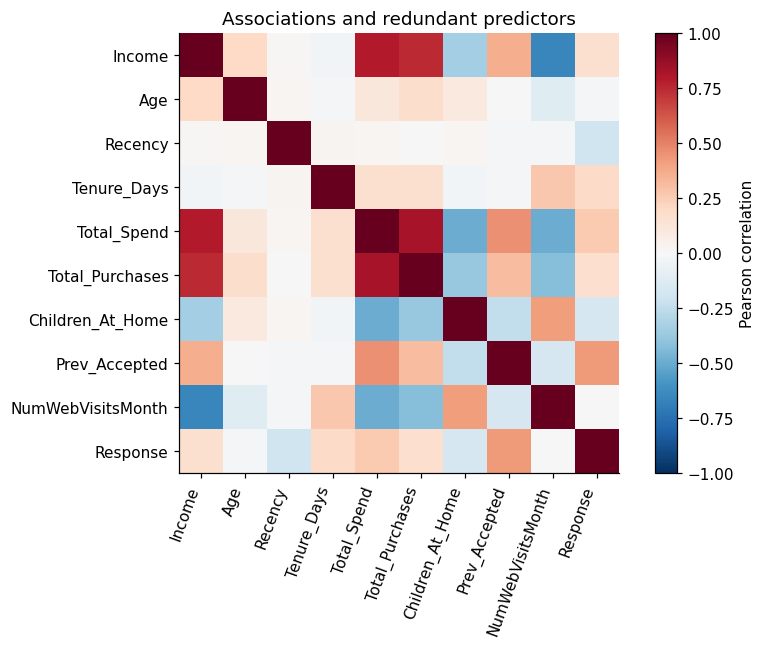

,correlation
Prev_Accepted,0.426
Total_Spend,0.266
Recency,-0.199
Tenure_Days,0.194
Children_At_Home,-0.169
Total_Purchases,0.164
Income,0.161
Age,-0.019
NumWebVisitsMonth,-0.004


**Interpretation:** group response differences and correlated spend features warrant a fairness audit and cautious explanation. Correlations identify associations; they do not establish marketing effects, individual preferences or legitimate grounds to exclude a group.

In [7]:
# EDA-only grouping; inferential audit quartiles are later fitted separately per training fold.
eda_income_cuts = df.Income.dropna().quantile([.25,.5,.75]).tolist()
eda_groups = make_sensitive(df, eda_income_cuts)
fig,axes=plt.subplots(1,3,figsize=(13,3.8))
for ax,col in zip(axes,["income_quartile","children_at_home","education"]):
    table=df.assign(group=eda_groups[col]).groupby("group").Response.agg(["mean","size"])
    ax.bar(table.index,table["mean"],color="#247b91");ax.axhline(prevalence,color="#9b4f34",ls="--")
    ax.set_title(col.replace("_"," "));ax.tick_params(axis="x",rotation=35)
    ax.set_ylabel("Historical response rate")
    for i,row in enumerate(table.itertuples()): ax.text(i,row.mean+.007,f"n={row.size}",ha="center",fontsize=8)
save_plot("03_group_response")
corr_features=["Income","Age","Recency","Tenure_Days","Total_Spend","Total_Purchases","Children_At_Home","Prev_Accepted","NumWebVisitsMonth"]
corr=eda[corr_features].assign(Response=df.Response).corr()
fig,ax=plt.subplots(figsize=(8,6))
im=ax.imshow(corr,vmin=-1,vmax=1,cmap="RdBu_r")
ax.set_xticks(range(len(corr)));ax.set_xticklabels(corr.columns,rotation=70,ha="right")
ax.set_yticks(range(len(corr)));ax.set_yticklabels(corr.index)
fig.colorbar(im,ax=ax,label="Pearson correlation")
ax.set_title("Associations and redundant predictors")
save_plot("04_correlations")
display(corr.Response.drop("Response").sort_values(key=abs,ascending=False).to_frame("correlation").round(3))
display(Markdown("**Interpretation:** group response differences and correlated spend features warrant a fairness audit and cautious explanation. Correlations identify associations; they do not establish marketing effects, individual preferences or legitimate grounds to exclude a group."))

## Step 4 Model implementation and selection

The four algorithms provide complementary baselines: a regularised linear classifier, bagged trees, boosted trees and an RBF support-vector classifier. All receive the same search budget and the same inner group folds. Class weights are fitted from each model-fitting partition. The same `predict_proba` output is used for ranking and validation/test threshold policies, avoiding SVM decision-rule mismatches.

**Frozen decision sequence in every outer fold**
1. Reserve the outer evaluation fold with no matching profile groups in development.
2. Split development into model-fitting and policy-validation groups.
3. Tune each algorithm on model-fitting data only, including preprocessing and feature selection. Select the largest mean inner ROC-AUC; deterministic name order breaks exact ties.
4. Fit the global F1 threshold on policy validation. Apply the prespecified children-at-home adjustment, selecting the smallest alpha in 0, 0.05, …, 1 that attains the illustrative 0.80 selection ratio there. If no alpha succeeds, retain the global policy and explicitly flag that failure.
5. Evaluate the frozen models and the selected procedure on the outer fold. Do not change the algorithm, attribute, budget or alpha using that fold.

Nested evaluation estimates this complete selection procedure. It does not make the historical dataset externally representative. AUC and other outer results below are reporting evidence, not a second rule for choosing the final candidate. Fitting eight configurations is a bounded comparison, not exhaustive optimisation.

In [8]:
# Main training cell: all learned preprocessing and selection are inside the folds.
comparison, outer_predictions, outer_policies = run_nested(df, groups, ROOT, **CONFIG)
write_json(ROOT / "reports/evaluation_contract.json", {
    "estimate": "Grouped nested internal validation of the complete model and targeting-policy selection procedure",
    "historical_data_previously_explored": True,
    "final_candidate_selection": "Highest inner CV ROC-AUC on a separate final fit partition",
    "targeting_attribute": "children_at_home, prespecified",
    "top_fraction_alternative": 0.20,
    "outer_test_used_for_decision_selection": False,
    "hyperparameter_configurations_per_algorithm": CONFIG["n_iter"]})
metrics_cols=["roc_auc","average_precision","f1","precision","recall","contact_fraction"]
comparison_summary=comparison.groupby("model")[metrics_cols].agg(["mean","std"])
display(comparison_summary.round(3))
comparison_summary.to_csv(ROOT / "reports/tables/model_outer_summary.csv")
selected_folds=comparison.loc[comparison.chosen_by_inner_cv]
display(selected_folds[["fold","model","inner_cv_auc"]+metrics_cols].round(3))
policy_diagnostics=pd.DataFrame([{"fold":p["fold"],"model":p["selected_model"],"policy_status":p["policy"]["status"],
    "alpha":p["policy"]["alpha"],"validation_selection_ratio":p["policy"]["validation_metrics"]["selection_rate_ratio"],
    "fit_rows":p["fit_rows"],"validation_rows":p["validation_rows"],"test_rows":p["test_rows"]} for p in outer_policies])
display(policy_diagnostics)
policy_diagnostics.to_csv(ROOT / "reports/tables/nested_policy_diagnostics.csv",index=False)

OUTER FOLD 1/5


  Logistic Regression: inner CV AUC 0.8978


  Random Forest: inner CV AUC 0.8743


  XGBoost: inner CV AUC 0.8900


  SVM RBF: inner CV AUC 0.8906


...

  SVM RBF: inner CV AUC 0.8962


  Frozen inner-CV choice: XGBoost


roc_auc        average_precision            f1         \
                       mean    std              mean    std   mean    std   
model                                                                       
Logistic Regression   0.892  0.018             0.653  0.069  0.537  0.104   
Random Forest         0.882  0.039             0.588  0.137  0.509  0.097   
SVM RBF               0.898  0.022             0.623  0.104  0.548  0.035   
XGBoost               0.901  0.028             0.656  0.095  0.515  0.065   

                    precision        recall        contact_fraction         
                         mean    std   mean    std             mean    std  
model                                                                       
Logistic Regression     0.531  0.110  0.550  0.121            0.157  0.037  
Random Forest           0.471  0.074  0.576  0.171            0.186  0.063  
SVM RBF                 0.553  0.107  0.568  0.108            0.159  0.045  
XGBoost                 0.520  0.100  0.536  0.122            0.162  0.060

,fold,model,inner_cv_auc,roc_auc,average_precision,f1,precision,recall,contact_fraction
0,1,Logistic Regression,0.898,0.911,0.657,0.652,0.611,0.698,0.162
4,2,Logistic Regression,0.905,0.904,0.692,0.570,0.515,0.638,0.217
11,3,SVM RBF,0.892,0.899,0.727,0.554,0.737,0.444,0.084
14,4,XGBoost,0.900,0.876,0.595,0.519,0.471,0.580,0.194
18,5,XGBoost,0.906,0.869,0.523,0.431,0.394,0.475,0.159


,fold,model,policy_status,alpha,validation_selection_ratio,fit_rows,validation_rows,test_rows
0,1,Logistic Regression,target_achieved_on_validation,0.75,0.800499,1435,357,444
1,2,Logistic Regression,target_achieved_on_validation,1.00,0.987884,1427,352,457
2,3,SVM RBF,target_achieved_on_validation,0.90,0.852459,1438,348,450
3,4,XGBoost,target_achieved_on_validation,0.90,0.802207,1445,353,438
4,5,XGBoost,target_achieved_on_validation,0.80,0.803429,1428,361,447


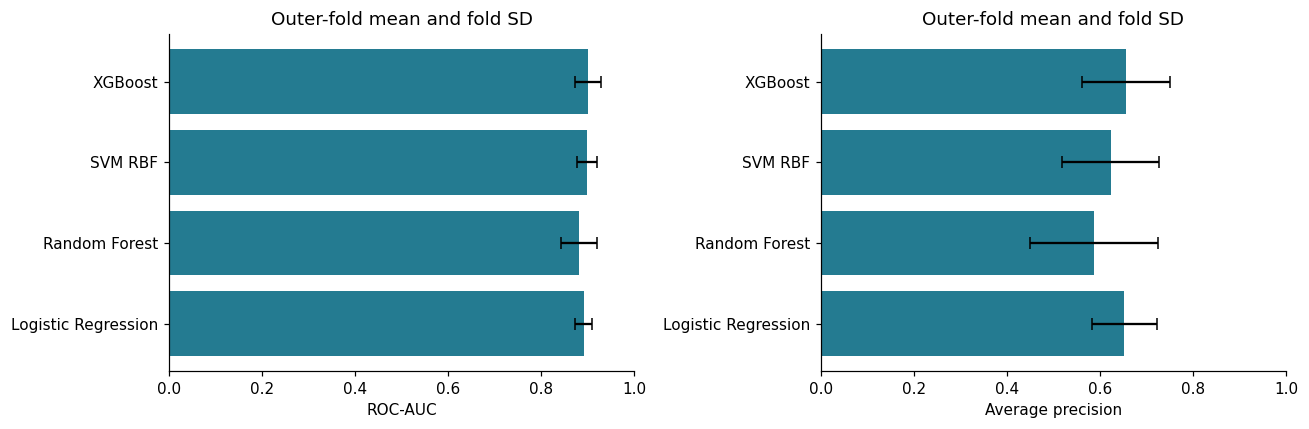

**Model-selection evidence:** Logistic Regression selected in 2/5 outer development folds; XGBoost selected in 2/5 outer development folds; SVM RBF selected in 1/5 outer development folds. The error bars show fold variability, not confidence intervals. A small average difference alone is insufficient to establish a definitive winner.

In [9]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,metric,label in [(axes[0],"roc_auc","ROC-AUC"),(axes[1],"average_precision","Average precision")]:
    stats=comparison.groupby("model")[metric].agg(["mean","std"])
    ax.barh(stats.index,stats["mean"],xerr=stats["std"],color="#247b91",capsize=4)
    ax.set_xlabel(label);ax.set_xlim(0,1);ax.set_title("Outer-fold mean and fold SD")
save_plot("05_model_comparison")
selection_counts=selected_folds.model.value_counts()
display(Markdown("**Model-selection evidence:** " + "; ".join(f"{name} selected in {n}/{CONFIG['outer_folds']} outer development folds" for name,n in selection_counts.items()) + ". The error bars show fold variability, not confidence intervals. A small average difference alone is insufficient to establish a definitive winner."))

### Complete-policy performance and fixed-budget alternative

Each customer below is evaluated once by a model and policy that did not fit that customer's profile group. Pooled metrics describe this procedure across five separately trained models. Income-quartile group labels use each fold's training-derived cutpoints. A mean of fold AUCs and a pooled AUC are distinct summaries and are both labelled. Different fold models can have different uncalibrated score scales, so mean outer-fold AUC is the primary ranking estimate; pooled AUC and AP are supplementary summaries.

The top-20% comparison fixes the contact budget before evaluation. There is no test-label search for a retrospectively profitable campaign size. “Observed-label value” applies assumed economics to historical outcomes and is not measured incremental profit.

,selected_n,tp,precision,recall,f1,contact_fraction,observed_label_profit_proxy,observed_label_roi_proxy,cost_per_observed_responder,response_concentration_lift
Selected fairness-adjusted policy,365,191,0.523288,0.571856,0.546495,0.163238,1006.0,0.918721,5.733,3.503207
Global F1 policy,329,198,0.601824,0.592814,0.597285,0.147138,1191.0,1.206687,4.985,4.028975
Fixed top 20%,449,231,0.514477,0.691617,0.590038,0.200805,1194.0,0.886414,5.831,3.444221
Contact everyone,2236,334,0.149374,1.0,0.259922,1.0,-3034.0,-0.452296,20.084,1.0
Contact nobody,0,0,None,0.0,0.0,0.0,0.0,None,NaN,NaN


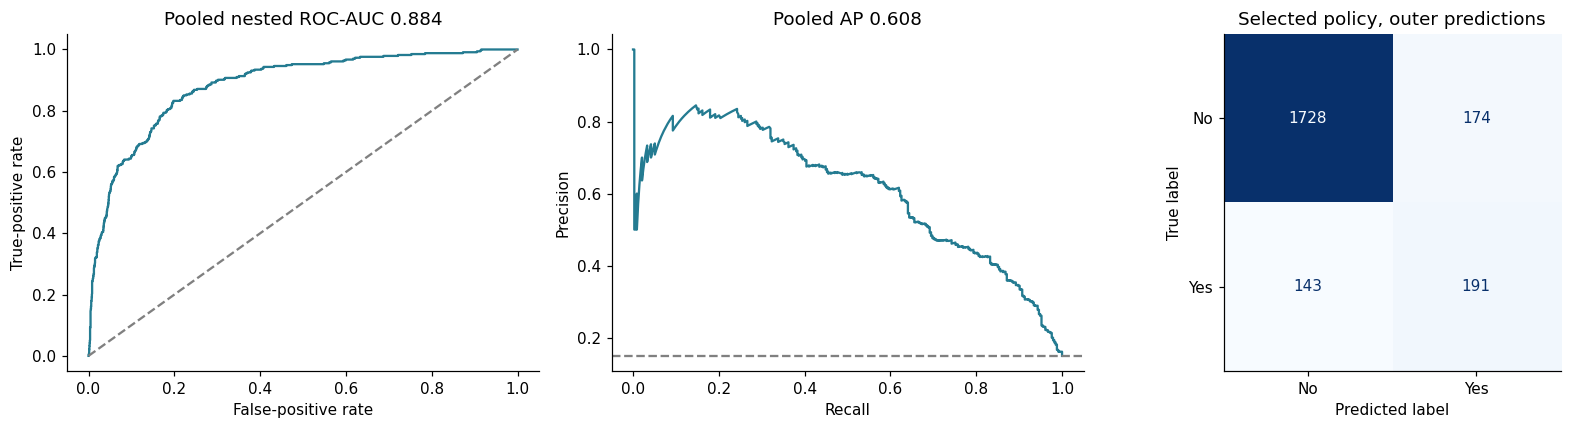

In [10]:
y_o=outer_predictions.y.to_numpy(); p_o=outer_predictions.score.to_numpy()
policy_columns={"Selected fairness-adjusted policy":"policy_pred","Global F1 policy":"global_pred","Fixed top 20%":"top20_pred"}
policy_metrics={name:evaluate_predictions(y_o,p_o,outer_predictions[col].to_numpy()) for name,col in policy_columns.items()}
policy_metrics["Contact everyone"]=evaluate_predictions(y_o,p_o,np.ones(len(y_o),dtype=int))
policy_metrics["Contact nobody"]=evaluate_predictions(y_o,p_o,np.zeros(len(y_o),dtype=int))
policy_table=pd.DataFrame(policy_metrics).T
responder_counts=pd.to_numeric(policy_table.tp)
policy_table["cost_per_observed_responder"]=pd.to_numeric(policy_table.assumed_contact_spend) / responder_counts.where(responder_counts.ne(0))
policy_table["response_concentration_lift"]=policy_table.precision/prevalence
show_cols=["selected_n","tp","precision","recall","f1","contact_fraction","observed_label_profit_proxy","observed_label_roi_proxy","cost_per_observed_responder","response_concentration_lift"]
display(policy_table[show_cols].round(3))
policy_table.to_csv(ROOT / "reports/tables/policy_comparison.csv")
write_json(ROOT / "reports/policy_comparison.json",policy_metrics)
fig,axes=plt.subplots(1,3,figsize=(15,4))
fpr,tpr,_=roc_curve(y_o,p_o);axes[0].plot(fpr,tpr,color="#247b91");axes[0].plot([0,1],[0,1],ls="--",color="gray")
axes[0].set(xlabel="False-positive rate",ylabel="True-positive rate",title=f"Pooled nested ROC-AUC {roc_auc_score(y_o,p_o):.3f}")
pr,re,_=precision_recall_curve(y_o,p_o);axes[1].plot(re,pr,color="#247b91");axes[1].axhline(prevalence,ls="--",color="gray")
axes[1].set(xlabel="Recall",ylabel="Precision",title=f"Pooled AP {average_precision_score(y_o,p_o):.3f}")
ConfusionMatrixDisplay.from_predictions(y_o,outer_predictions.policy_pred,display_labels=["No","Yes"],ax=axes[2],colorbar=False,cmap="Blues")
axes[2].grid(False);axes[2].set_title("Selected policy, outer predictions")
save_plot("06_selected_policy")

In [11]:
# Cluster bootstrap: matching customer profiles resample together.
# Conditional on already fitted fold models; does not rerun model selection.
rng=np.random.default_rng(RANDOM_STATE)
blocks=[g.index.to_numpy() for _,g in outer_predictions.groupby("group")]
boot=[]
for _ in range(400):
    idx=np.concatenate([blocks[i] for i in rng.integers(0,len(blocks),len(blocks))])
    b=outer_predictions.iloc[idx]
    met=evaluate_predictions(b.y,b.score,b.policy_pred)
    rates=b.groupby("children_at_home").policy_pred.mean()
    boot.append({"roc_auc":met["roc_auc"],"average_precision":met["average_precision"],"f1":met["f1"],
                 "recall":met["recall"],"precision":met["precision"],
                 "children_selection_ratio":rates.min()/rates.max() if rates.max()>0 else np.nan})
intervals=pd.DataFrame(boot).quantile([.025,.975]).T
intervals.columns=["conditional_95pct_lower","conditional_95pct_upper"]
display(intervals.round(3))
intervals.to_csv(ROOT / "reports/tables/conditional_bootstrap_intervals.csv")
display(Markdown("**Uncertainty limitation:** these profile-cluster bootstrap intervals hold fold-trained models fixed. They describe sensitivity to the evaluated customer sample, not all model-training uncertainty. Outer folds also share some training records. Small differences in models or fairness metrics should therefore be interpreted cautiously."))

,conditional_95pct_lower,conditional_95pct_upper
roc_auc,0.863,0.903
average_precision,0.555,0.666
f1,0.500,0.593
recall,0.514,0.628
precision,0.475,0.576
children_selection_ratio,0.645,0.972


**Uncertainty limitation:** these profile-cluster bootstrap intervals hold fold-trained models fixed. They describe sensitivity to the evaluated customer sample, not all model-training uncertainty. Outer folds also share some training records. Small differences in models or fairness metrics should therefore be interpreted cautiously.

## Step 5 Ethical AI and bias auditing

The relevant decision is access to a marketing offer. Both unwanted contact and missed beneficial offers can matter. Age, income, education, children living at home and partnership status are descriptive audit axes; the dataset contains no gender or race information. Missing income and unknown marital labels retain explicit audit groups.

The mitigation axis is **children at home**, specified before evaluation because the earlier project identified household access as a concern. The numerical 0.80 target is an illustrative design choice, not evidence of legal compliance or fairness. It may trade off against predictive performance, other groups and equalised odds.

Demographic parity gap measures the maximum minus minimum selection rate. The selection ratio is the minimum divided by maximum rate. Equalised-odds gap is the larger of TPR/FPR gaps. Undefined rates remain missing rather than being treated as zero. Group counts and Wilson intervals are displayed; those intervals assume independent Bernoulli outcomes within groups, so the profile-cluster bootstrap is the more suitable overall sensitivity check for repeated profiles.

In [12]:
sensitive_columns=["age_band","income_quartile","education","children_at_home","household"]
audits={}
for name,col in policy_columns.items():
    audits[name]=audit_fairness(y_o,outer_predictions[col].to_numpy(),outer_predictions[sensitive_columns])
    pd.DataFrame(audits[name]["groups"]).to_csv(ROOT / "reports/tables" / (col+"_fairness_groups.csv"),index=False)
    pd.DataFrame(audits[name]["summary"]).to_csv(ROOT / "reports/tables" / (col+"_fairness_summary.csv"),index=False)
write_json(ROOT / "reports/fairness_audits.json",audits)
nested_audit=pd.DataFrame(audits["Selected fairness-adjusted policy"]["summary"])
display(Markdown("**All-group audit of the nested selection procedure.** Undefined equalised-odds values indicate that at least one included group lacks positive or negative outcomes."))
display(nested_audit.round(3))
display(pd.DataFrame(audits["Selected fairness-adjusted policy"]["groups"]).round(3))
axis_ratios=nested_audit.set_index("attribute").disparate_impact_ratio
display(Markdown(f"**Remaining disparities:** the pooled children-at-home selection ratio is {axis_ratios['children_at_home']:.3f}. "
    + "Other ratios are " + "; ".join(f"{name.replace('_',' ')} {ratio:.3f}" for name,ratio in axis_ratios.items() if name!="children_at_home")
    + ". The adjustment targets one axis and does not establish fairness overall. Interpret groups with very few customers with particular caution."))

**All-group audit of the nested selection procedure.** Undefined equalised-odds values indicate that at least one included group lacks positive or negative outcomes.

,attribute,group_count,minimum_group_n,demographic_parity_gap,disparate_impact_ratio,tpr_gap,fpr_gap,equalised_odds_gap,all_groups_have_both_outcomes
0,age_band,4,107,0.068,0.656,0.069,0.041,0.069,True
1,income_quartile,5,24,0.154,0.351,0.629,0.035,0.629,True
2,education,5,54,0.128,0.420,0.614,0.053,0.614,True
3,children_at_home,2,637,0.037,0.803,0.032,0.045,0.045,True
4,household,3,4,0.377,0.245,0.098,0.429,0.429,True


,attribute,group,n,positive_n,negative_n,selected_n,tp,fp,tn,fn,selection_rate,tpr,fpr,precision,selection_wilson_low,selection_wilson_high,tpr_wilson_low,tpr_wilson_high
0,age_band,35–49,1029,140,889,180,85,95,794,55,0.175,0.607,0.107,0.472,0.153,0.199,0.524,0.684
1,age_band,50–64,676,87,589,87,48,39,550,39,0.129,0.552,0.066,0.552,0.106,0.156,0.447,0.652
2,age_band,65+,107,26,81,21,14,7,74,12,0.196,0.538,0.086,0.667,0.132,0.281,0.355,0.712
3,age_band,Under 35,424,81,343,77,44,33,310,37,0.182,0.543,0.096,0.571,0.148,0.221,0.435,0.647
4,income_quartile,Q1,557,56,501,69,32,37,464,24,0.124,0.571,0.074,0.464,0.099,0.154,0.441,0.692
5,income_quartile,Q2,550,72,478,89,37,52,426,35,0.162,0.514,0.109,0.416,0.133,0.195,0.401,0.626
6,income_quartile,Q3,536,54,482,70,27,43,439,27,0.131,0.500,0.089,0.386,0.105,0.162,0.371,0.629
7,income_quartile,Q4,569,151,418,135,95,40,378,56,0.237,0.629,0.096,0.704,0.204,0.274,0.550,0.702
8,income_quartile,Unknown,24,1,23,2,0,2,21,1,0.083,0.000,0.087,0.000,0.023,0.258,0.000,0.793
9,education,2n Cycle,201,22,179,24,10,14,165,12,0.119,0.455,0.078,0.417,0.082,0.172,0.269,0.653


**Remaining disparities:** the pooled children-at-home selection ratio is 0.803. Other ratios are age band 0.656; income quartile 0.351; education 0.420; household 0.245. The adjustment targets one axis and does not establish fairness overall. Interpret groups with very few customers with particular caution.

Audit table columns: ['attribute', 'group', 'n', 'positive_n', 'negative_n', 'selected_n', 'tp', 'fp', 'tn', 'fn', 'selection_rate', 'tpr', 'fpr', 'precision', 'selection_wilson_low', 'selection_wilson_high', 'tpr_wilson_low', 'tpr_wilson_high']


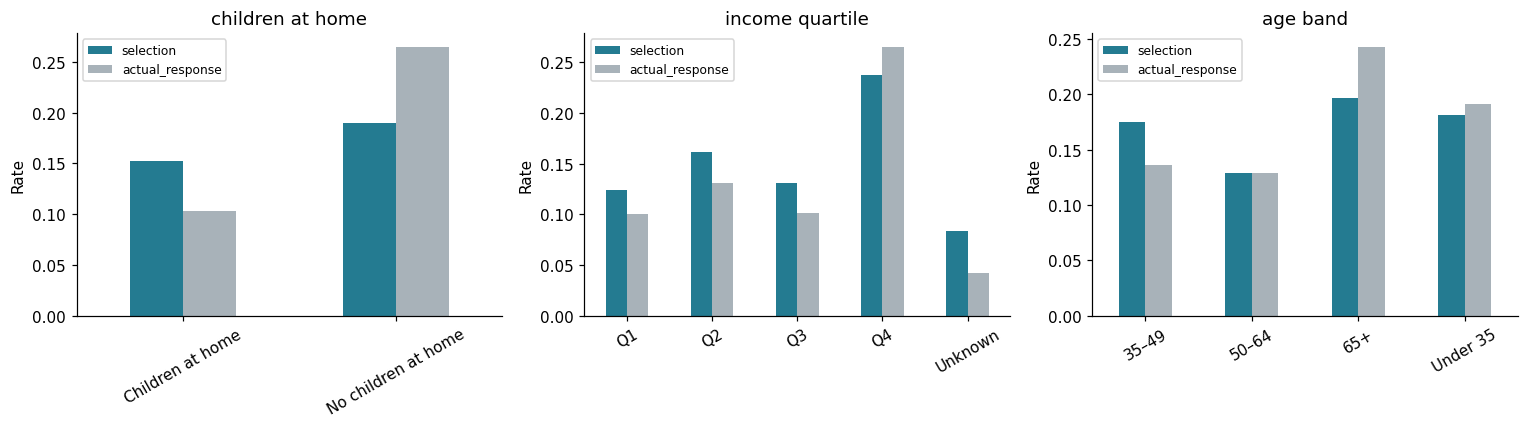

**Audit interpretation:** validation attainment of the 0.80 target does not ensure attainment on outer folds or for other attributes. Compare group denominators, uncertainty and equalised odds before recommending use. Historical response disparities may reflect opportunity, sampling or measurement differences; they are not proof of intrinsic preferences.

In [13]:
fair_groups=pd.DataFrame(audits["Selected fairness-adjusted policy"]["groups"])
print("Audit table columns:",list(fair_groups.columns))
# Direct group-rate chart uses the actual final decisions, independent of field aliases.
fig,axes=plt.subplots(1,3,figsize=(14,4))
for ax,col in zip(axes,["children_at_home","income_quartile","age_band"]):
    t=outer_predictions.groupby(col).agg(selection=("policy_pred","mean"),actual_response=("y","mean"),n=("y","size"))
    t[["selection","actual_response"]].plot.bar(ax=ax,color=["#247b91","#a8b2b9"],rot=30)
    ax.set_title(col.replace("_"," "));ax.set_xlabel("");ax.set_ylabel("Rate")
    ax.legend(fontsize=8)
save_plot("07_final_policy_groups")
display(Markdown("**Audit interpretation:** validation attainment of the 0.80 target does not ensure attainment on outer folds or for other attributes. Compare group denominators, uncertainty and equalised odds before recommending use. Historical response disparities may reflect opportunity, sampling or measurement differences; they are not proof of intrinsic preferences."))

### Business sensitivity and consistent policy reporting

The same fairness-adjusted decisions supply every value calculation in this section. The contact cost and response value are scenario assumptions, not verified current prices or margins. Values at different assumptions are a sensitivity analysis; the scenario with the highest test value is not used to change the selected policy.

In [14]:
contacted=int(outer_predictions.policy_pred.sum())
responders=int(((outer_predictions.policy_pred==1)&(outer_predictions.y==1)).sum())
sensitivity=pd.DataFrame([{ "value_per_response":v,"cost_per_contact":c,
                           "observed_label_value":responders*v-contacted*c}
                         for v in [6,11,16] for c in [1,3,5]])
display(sensitivity.pivot(index="value_per_response",columns="cost_per_contact",values="observed_label_value"))
sensitivity.to_csv(ROOT / "reports/tables/value_sensitivity.csv",index=False)
mean_auc=float(selected_folds.roc_auc.mean())
top_lift=float(policy_table.loc["Fixed top 20%","response_concentration_lift"])
reference_value=float(policy_table.loc["Selected fairness-adjusted policy","observed_label_profit_proxy"])
gates=pd.DataFrame({"criterion":["Mean outer AUC >= 0.80","Top-20% response concentration >= 2x","Positive illustrative selected-policy value"],
                    "observed":[mean_auc,top_lift,reference_value],
                    "met":[mean_auc>=.80,top_lift>=2,reference_value>0]})
display(gates)
display(Markdown("These technical checks do not authorise deployment. A prospective pilot must verify data availability, consent, offer eligibility, actual costs and group outcomes."))

cost_per_contact,1,3,5
value_per_response,,,
6,781,51,-679
11,1736,1006,276
16,2691,1961,1231


,criterion,observed,met
0,Mean outer AUC >= 0.80,0.891916,True
1,Top-20% response concentration >= 2x,3.444221,True
2,Positive illustrative selected-policy value,1006.000000,True


These technical checks do not authorise deployment. A prospective pilot must verify data availability, consent, offer eligibility, actual costs and group outcomes.

## Final candidate and reproducible persistence

The final candidate is chosen with a separate deterministic group split of the whole eligible dataset. Its fitting partition supplies the same inner-CV algorithm selection; its validation partition supplies only threshold fitting. Outer results do not determine the final algorithm. The model is **not refitted after choosing thresholds**, because refitting could change the score scale.

This means the saved candidate leaves its policy-validation customers out of model fitting. It sacrifices some fitting data to preserve a consistent estimator-policy pairing. Its validation metrics are not an independent performance estimate; the nested procedure above provides the internal evaluation. Save and load `final_bundle.joblib`, which contains the whole pipeline, sensitive-group definitions through code, thresholds and metadata.

In [15]:
bundle,final_ranking,final_fit_idx,final_validation_idx = fit_final_candidate(
    df,groups,ROOT,inner_folds=CONFIG["inner_folds"],n_iter=CONFIG["n_iter"],seed=RANDOM_STATE)
display(final_ranking[["model","inner_cv_auc","inner_cv_sd","params"]])
print("Saved final candidate:",bundle["metadata"]["model"])
print("Global threshold:",round(bundle["policy"]["global_threshold"],4))
print("Fairness alpha:",bundle["policy"]["alpha"])
print("Policy fitting status:",bundle["policy"]["status"])
print("Final group thresholds:",bundle["policy"]["group_thresholds"])
print("Selected features:",bundle["metadata"]["selected_features"])
# A fresh load must reproduce the exact scores and contact decisions.
import joblib
loaded=joblib.load(ROOT / "models/final_bundle.joblib")
example=df.drop(columns="Response").iloc[final_validation_idx[:12]]
before=predict_bundle(bundle,example);after=predict_bundle(loaded,example)
np.testing.assert_allclose(before.score,after.score,rtol=0,atol=0)
np.testing.assert_array_equal(before.contact,after.contact)
print("Saved-pipeline score and policy roundtrip: PASS")
display(after)
candidate_validation=df.drop(columns="Response").iloc[final_validation_idx]
candidate_output=predict_bundle(bundle,candidate_validation)
candidate_sensitive=make_sensitive(candidate_validation,bundle["income_edges"])
candidate_audit=audit_fairness(df.Response.iloc[final_validation_idx].to_numpy(),candidate_output.contact.to_numpy(),candidate_sensitive)
write_json(ROOT / "reports/final_candidate_validation_audit.json",candidate_audit)
display(Markdown("**Saved candidate audit on its policy-validation partition.** These records fitted its thresholds, so this table is a development diagnostic, not independent test evidence."))
display(pd.DataFrame(candidate_audit["summary"]).round(3))

FINAL CANDIDATE: separate fit / policy-validation partition


  Logistic Regression: inner CV AUC 0.8989


  Random Forest: inner CV AUC 0.8760


  XGBoost: inner CV AUC 0.8946


  SVM RBF: inner CV AUC 0.9001


,model,inner_cv_auc,inner_cv_sd,params
3,SVM RBF,0.900132,0.013509,"{'select__percentile': 100, 'clf__gamma': 0.01..."
0,Logistic Regression,0.898876,0.012948,"{'select__percentile': 100, 'clf__penalty': 'l..."
2,XGBoost,0.894610,0.007390,"{'select__percentile': 80, 'clf__n_estimators'..."
1,Random Forest,0.875976,0.010902,"{'select__percentile': 80, 'clf__min_samples_l..."


Saved final candidate: SVM RBF
Global threshold: 0.134
Fairness alpha: 0.95
Policy fitting status: target_achieved_on_validation
Final group thresholds: {'Children at home': 0.0626109588003087, 'No children at home': 0.49893000500134005}
Selected features: ['Income', 'Recency', 'Complain', 'NumDealsPurchases', 'NumWebVisitsMonth', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Income_missing', 'Age', 'Tenure_Days', 'Children_At_Home', 'Has_Children_At_Home', 'Has_Partner', 'Household_Size_Proxy', 'Total_Spend', 'Total_Purchases', 'Spend_Per_Recorded_Purchase', 'No_Recorded_Purchases', 'Deal_Share_Proxy', 'Web_Share', 'Wine_Share', 'Meat_Share', 'Prev_Accepted', 'Spend_to_Income_Proxy', 'Education_Basic', 'Education_2n_Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marita

,score,contact
2,0.002683,0
7,0.127327,1
8,0.394830,1
14,0.111707,0
23,0.011507,0
28,0.018862,0
30,0.065840,0
33,0.859680,1
34,0.526790,1
35,0.008876,0


**Saved candidate audit on its policy-validation partition.** These records fitted its thresholds, so this table is a development diagnostic, not independent test evidence.

,attribute,group_count,minimum_group_n,demographic_parity_gap,disparate_impact_ratio,tpr_gap,fpr_gap,equalised_odds_gap,all_groups_have_both_outcomes
0,age_band,4,17,0.176,0.527,0.282,0.146,0.282,True
1,income_quartile,5,4,0.330,0.000,NaN,0.231,NaN,False
2,education,5,11,0.260,0.383,0.600,0.169,0.600,True
3,children_at_home,2,120,0.050,0.839,0.224,0.031,0.224,True
4,household,3,2,0.783,0.217,0.268,0.858,0.858,True


### Feature selection and model explainability

The feature-selection report shows the final candidate's fitted filter and retained variables. It is descriptive of that fitted model; selection can differ in other folds.

SHAP explains model output, not causal drivers of customer behaviour. Tree/linear explanations may use a raw margin or log-odds scale, stated in the plot notes. PDP/ICE changes raw Recency and raw web visits and reruns the full pipeline, so deterministic derived features remain consistent. Correlation with other unchanged raw inputs may still produce unusual records. No claim is made that the plotted sample rules out all heterogeneous subgroups.

{
  "model": "SVM RBF",
  "paths": {
    "feature_selection_table": "/Users/charlesleo/.codex/.chatgpt-projects/g-p-6a9d47b8885c8191817a17674c8f26cd/output/capstone-revised/reports/tables/final_feature_selection.csv",
    "shap_figure": "/Users/charlesleo/.codex/.chatgpt-projects/g-p-6a9d47b8885c8191817a17674c8f26cd/output/capstone-revised/reports/figures/explain_shap.png",
    "shap_importance_table": "/Users/charlesleo/.codex/.chatgpt-projects/g-p-6a9d47b8885c8191817a17674c8f26cd/output/capstone-revised/reports/tables/final_shap_importance.csv",
    "pdp_ice_figure": "/Users/charlesleo/.codex/.chatgpt-projects/g-p-6a9d47b8885c8191817a17674c8f26cd/output/capstone-revised/reports/figures/explain_pdp_ice.png",
    "pdp_table": "/Users/charlesleo/.codex/.chatgpt-projects/g-p-6a9d47b8885c8191817a17674c8f26cd/output/capstone-revised/reports/tables/final_pdp.csv",
    "summary": "/Users/charlesleo/.codex/.chatgpt-projects/g-p-6a9d47b8885c8191817a17674c8f26cd/output/capstone-revised/reports/

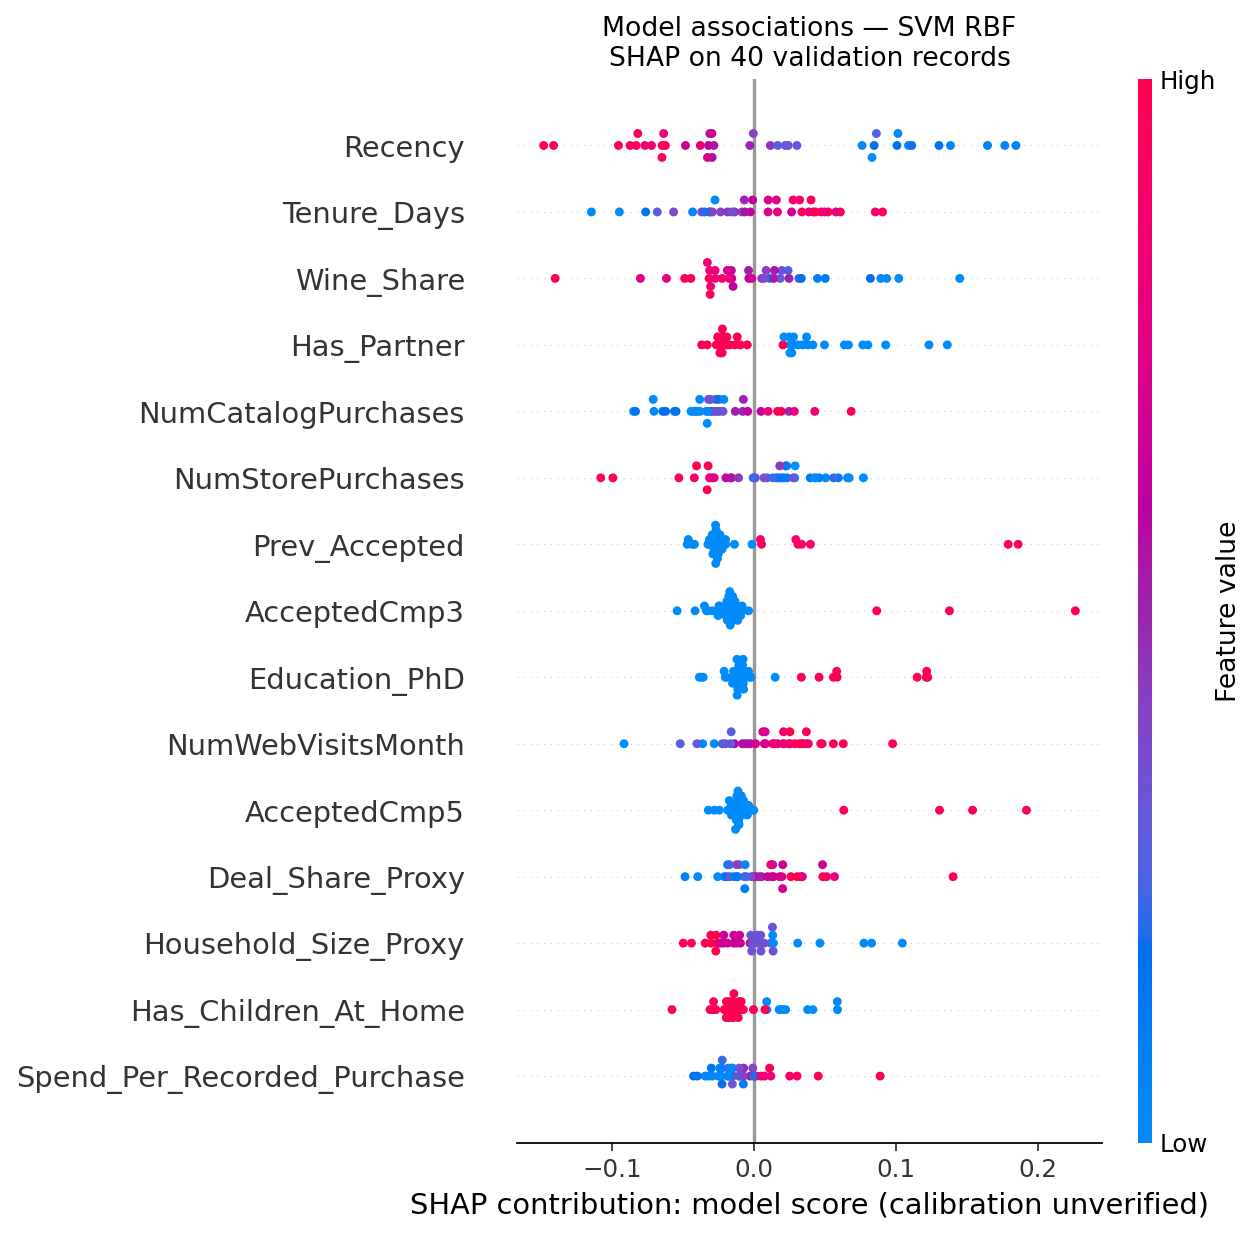

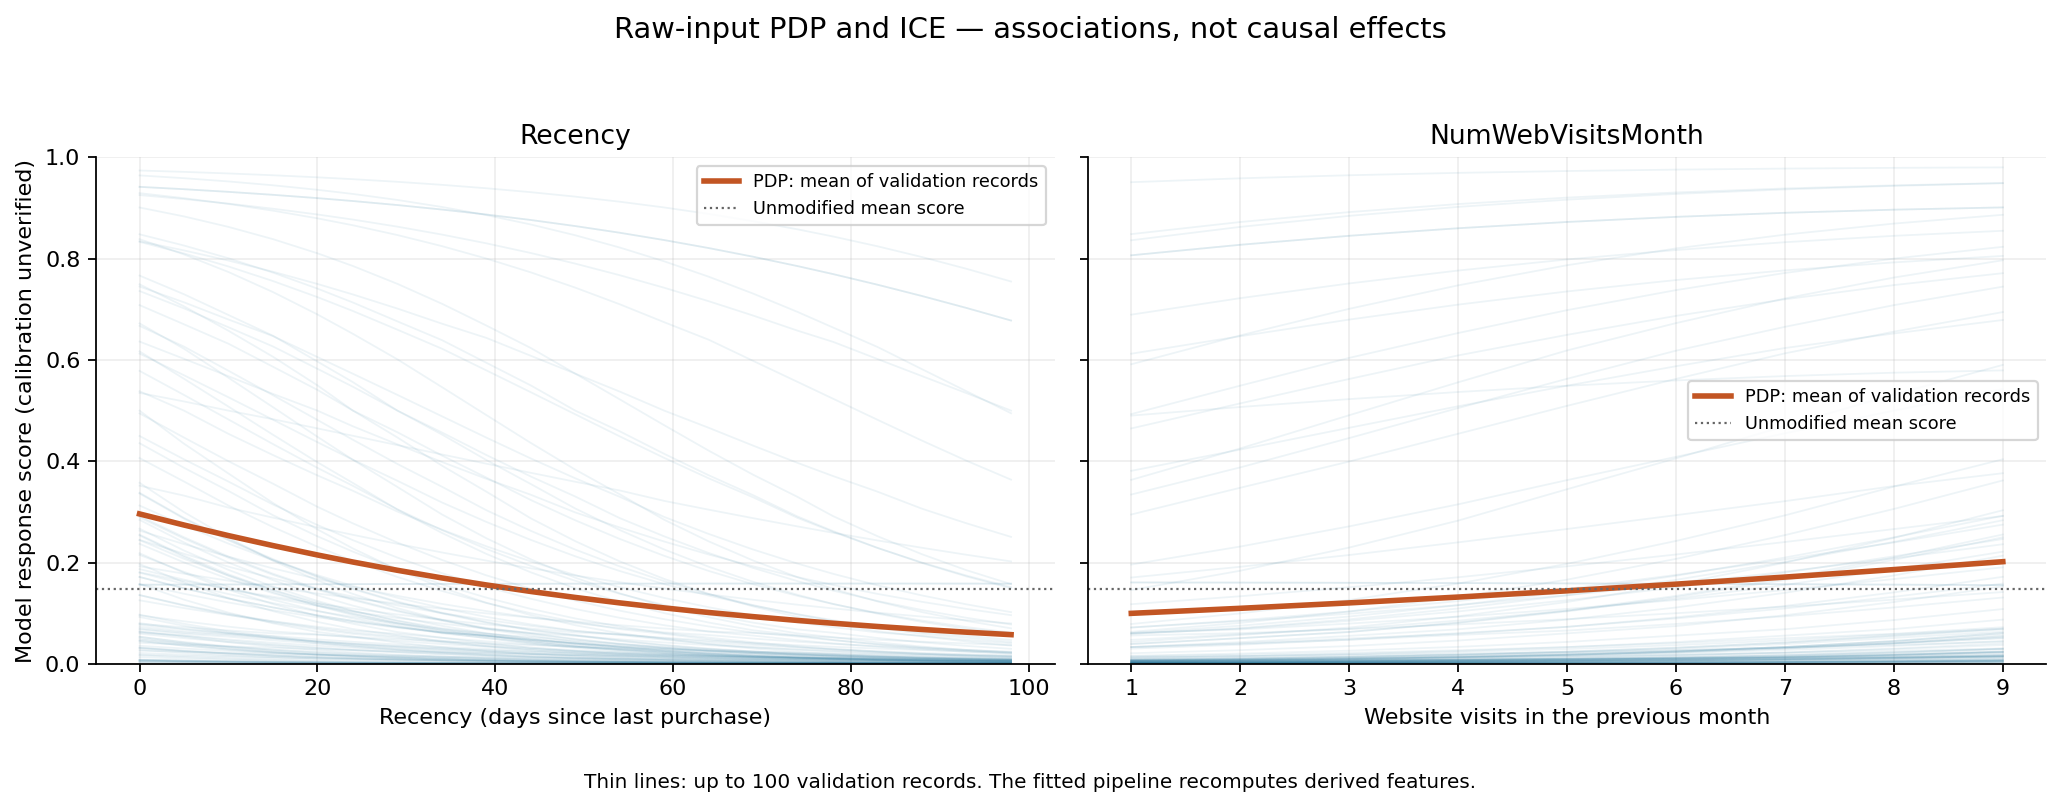

,feature,passed_variance_filter,anova_F,anova_p_value,anova_rank,selected_for_model,selection_percentile
0,Prev_Accepted,True,415.065781,3.672510e-83,1.0,True,100.0
1,AcceptedCmp5,True,232.518250,1.855002e-49,2.0,True,100.0
2,AcceptedCmp1,True,160.768061,2.409063e-35,3.0,True,100.0
3,Total_Spend,True,135.008473,3.835960e-30,4.0,True,100.0
4,AcceptedCmp3,True,131.654640,1.848193e-29,5.0,True,100.0
5,Spend_Per_Recorded_Purchase,True,128.670717,7.506049e-29,6.0,True,100.0
6,MntWines,True,119.866032,4.759514e-27,7.0,True,100.0
7,Spend_to_Income_Proxy,True,117.995150,1.152649e-26,8.0,True,100.0
8,NumCatalogPurchases,True,104.270737,7.812896e-24,9.0,True,100.0
9,MntMeatProducts,True,96.516521,3.183558e-22,10.0,True,100.0


,feature,mean_abs_SHAP,output_scale,explained_rows
0,Recency,0.074090,model score (calibration unverified),40
1,Tenure_Days,0.037981,model score (calibration unverified),40
2,Wine_Share,0.037958,model score (calibration unverified),40
3,Has_Partner,0.036676,model score (calibration unverified),40
4,NumCatalogPurchases,0.035864,model score (calibration unverified),40
5,NumStorePurchases,0.034577,model score (calibration unverified),40
6,Prev_Accepted,0.034560,model score (calibration unverified),40
7,AcceptedCmp3,0.029572,model score (calibration unverified),40
8,Education_PhD,0.028830,model score (calibration unverified),40
9,NumWebVisitsMonth,0.028014,model score (calibration unverified),40


In [16]:
from src.explainability import explain_candidate
explanation=explain_candidate(bundle,df.drop(columns="Response").iloc[final_fit_idx],
                              df.drop(columns="Response").iloc[final_validation_idx],ROOT,RANDOM_STATE)
print(json.dumps(json_safe(explanation),indent=2))
for filename in ["explain_shap.png","explain_pdp_ice.png"]:
    display(Image(filename=str(ROOT / "reports/figures" / filename),width=1000))
display(pd.read_csv(ROOT / "reports/tables/final_feature_selection.csv"))
display(pd.read_csv(ROOT / "reports/tables/final_shap_importance.csv").head(10))

## Supporting customer segmentation and PCA

This track groups the whole eligible snapshot without using Response as a clustering feature. Median imputation, selected log transforms and scaling precede Euclidean clustering. K-Means k=2–6 and Ward hierarchical clustering k=2–4 are compared with silhouette, Davies–Bouldin and Calinski–Harabasz scores. The reusable K-Means solution selects its k by the highest silhouette within that family. The best result across families is also disclosed; choosing a reusable centroid model does not establish universal superiority.

PCA describes variance and provides a two-dimensional visualisation. It is not part of the classifier validation path. Response rates are joined to completed clusters only as descriptive profiles, not used to choose the clustering solution. The k=3 alternative and seed stability make the earlier three-segment story testable rather than assumed.

{
  "task_type": "Descriptive unsupervised customer segmentation",
  "n_customers": 2236,
  "selected_k": 2,
  "selected_silhouette": 0.21609077178761296,
  "selection_rule": "Highest silhouette among KMeans k=2..6; ties prefer smaller k. Ward is a diagnostic comparator.",
  "best_candidate_overall": {
    "algorithm": "KMeans",
    "k": 2,
    "silhouette": 0.21609077178761296
  },
  "k3_silhouette": 0.20682349506494374,
  "features": [
    "Income",
    "Age_2014",
    "Recency",
    "Tenure_Days",
    "Total_Spend",
    "Total_Purchases",
    "Children_At_Home",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Wine_Spend_Share",
    "Meat_Spend_Share",
    "Web_Purchase_Share",
    "Catalog_Purchase_Share"
  ],
  "feature_notes": {
    "reference_date": "2014-06-30",
    "reference_date_reason": "Fixed near the last source enrollment date; avoids aging this historical snapshot to the execution year.",
    "age": "Approximate age: 2014 minus year of birth; exact birthday unavai

,algorithm,k,inertia,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster_n,largest_cluster_n
0,KMeans,2,22465.963288,0.216091,1.771387,656.502008,1100,1136
1,KMeans,3,18749.472913,0.206823,1.650319,614.451166,594,834
2,KMeans,4,17431.227900,0.180000,1.896320,496.680928,388,736
3,KMeans,5,16552.269245,0.140384,2.087405,421.733644,370,517
4,KMeans,6,15929.138573,0.128249,2.075542,367.878814,308,470
5,Ward,2,NaN,0.206697,1.800382,595.189156,869,1367
6,Ward,3,NaN,0.185619,1.753298,558.281019,522,869
7,Ward,4,NaN,0.153130,2.120405,438.012309,398,845


,Cluster,Customer_Count,Customer_Share,Income_mean,Age_2014_mean,Recency_mean,Tenure_Days_mean,Total_Spend_mean,Total_Purchases_mean,...,NumWebVisitsMonth_mean,Wine_Spend_Share_mean,Meat_Spend_Share_mean,Web_Purchase_Share_mean,Catalog_Purchase_Share_mean,Income_median,Total_Spend_median,Total_Purchases_median,Observed_Response_Rate
0,0,1100,0.49195,68696.591368,47.365455,49.370000,367.551818,1093.410909,18.566364,...,3.922727,0.513644,0.260983,0.298995,0.253554,68655.0,1056.5,18.0,0.198182
1,1,1136,0.50805,35727.783615,42.910211,48.870599,342.399648,134.008803,6.717430,...,6.670775,0.405672,0.238444,0.357920,0.077907,35688.0,70.0,6.0,0.102113


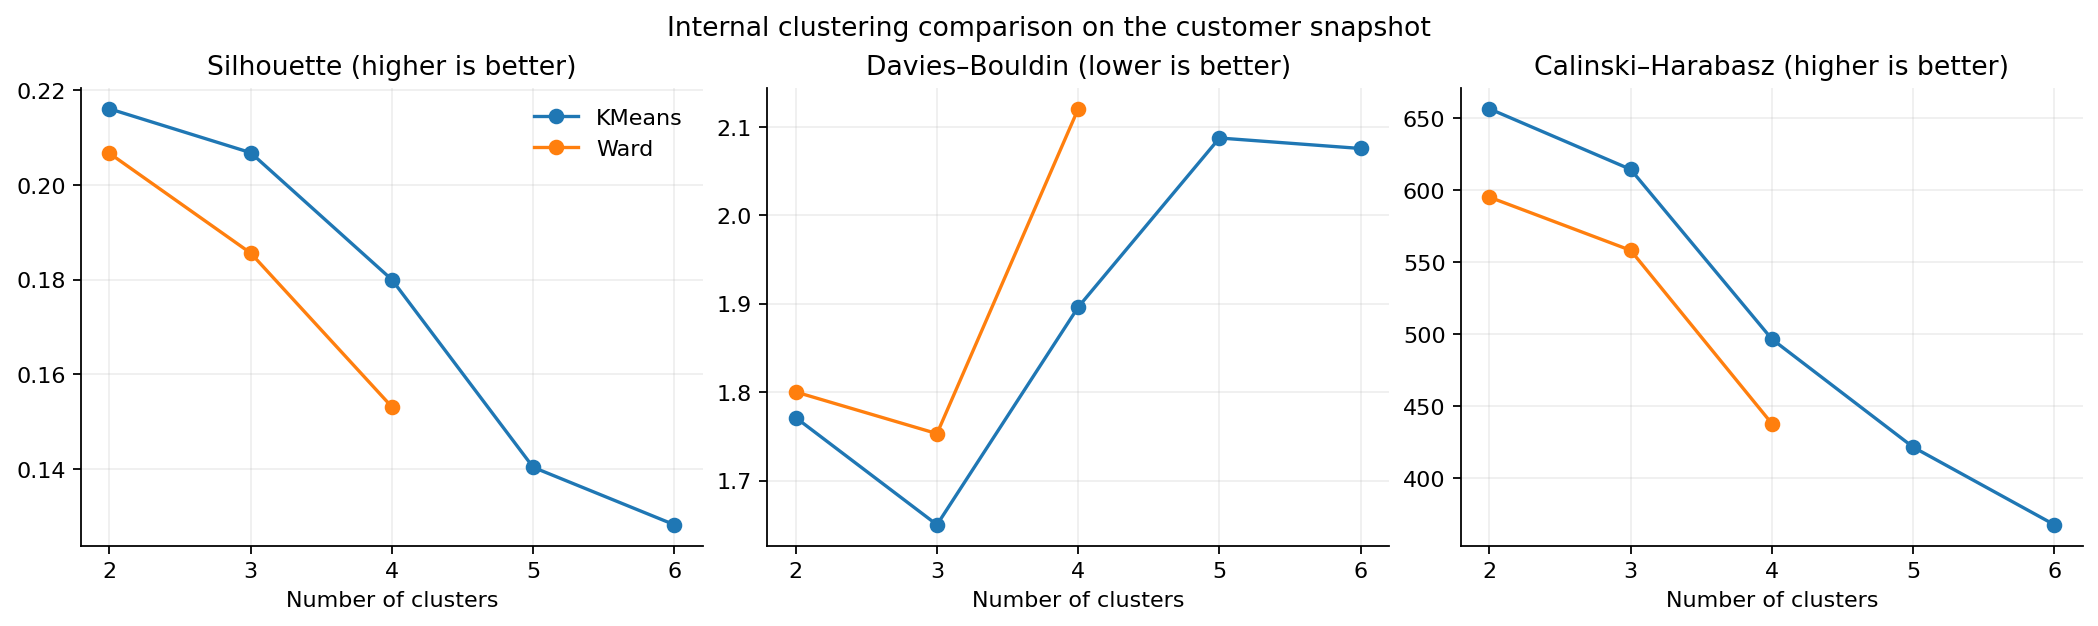

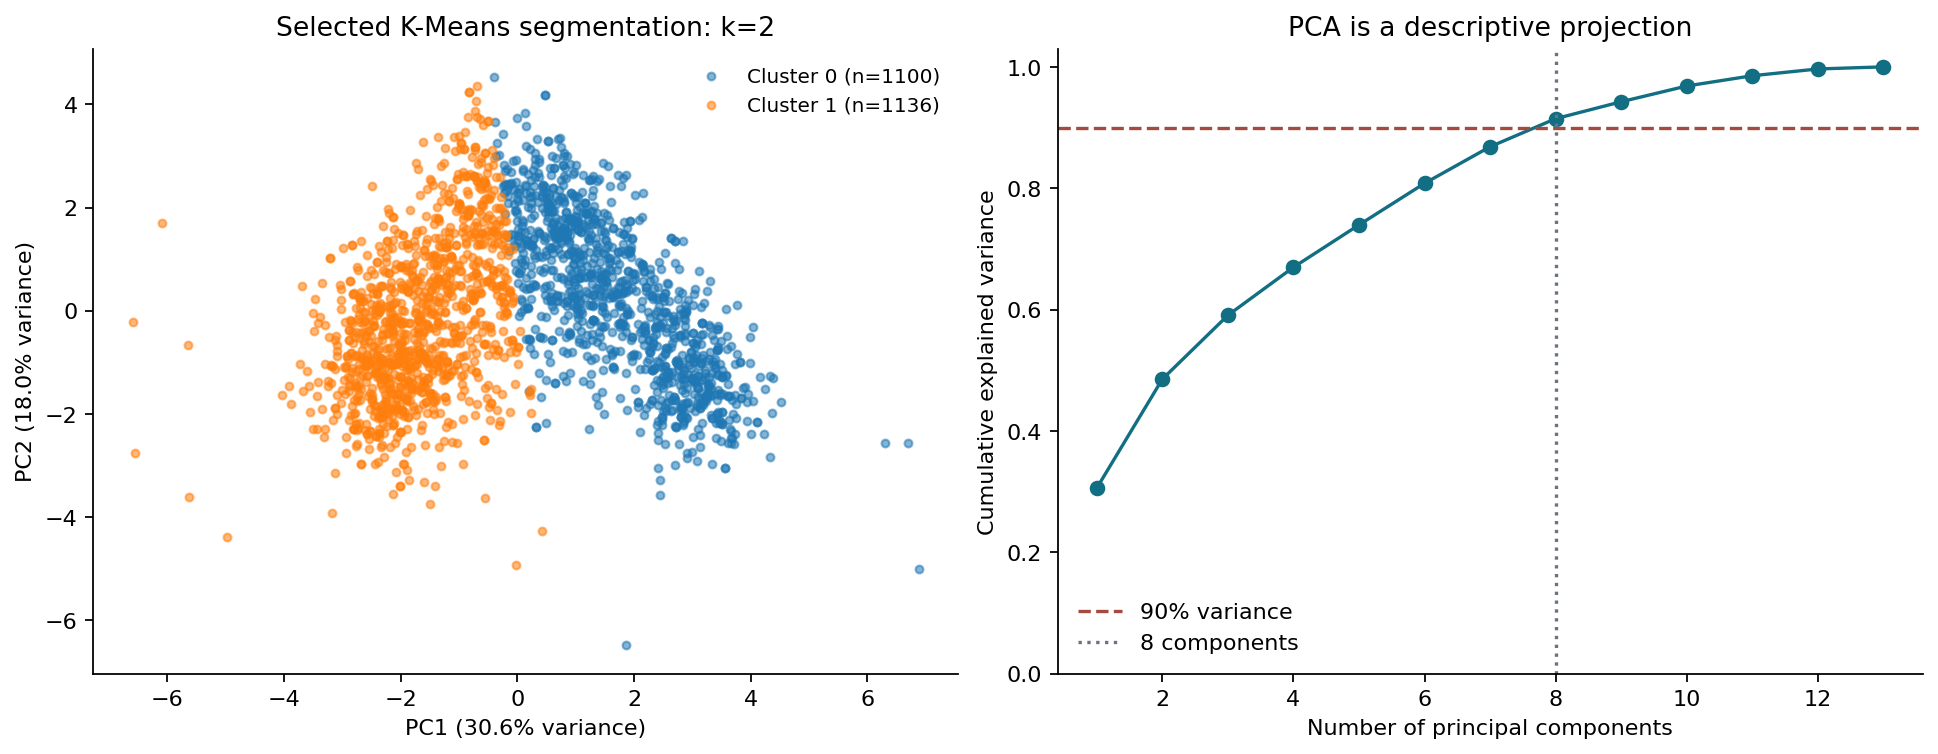

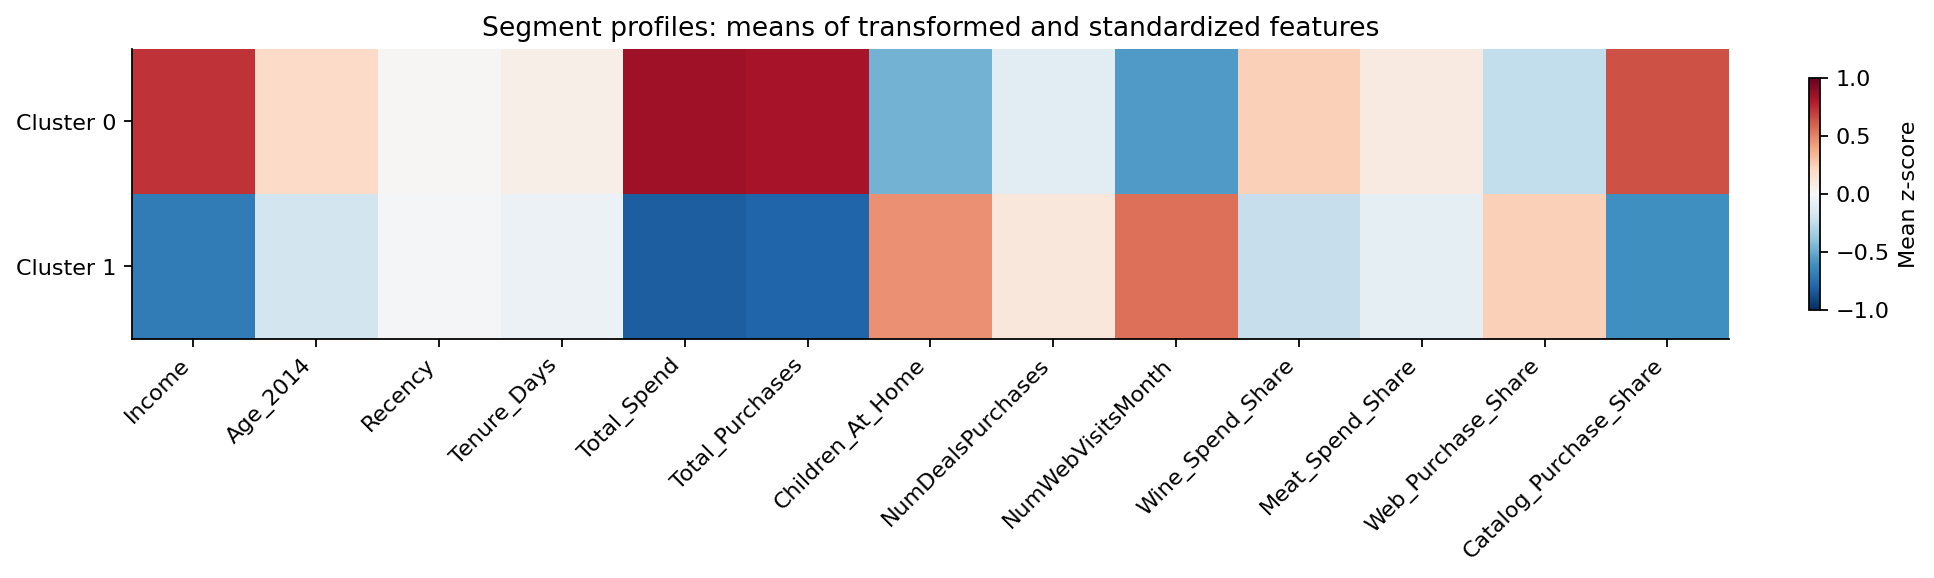

In [17]:
from src.segmentation import run_segmentation
segmentation=run_segmentation(df,ROOT,RANDOM_STATE)
print(json.dumps(json_safe(segmentation),indent=2))
write_json(ROOT / "reports/segmentation_summary.json",segmentation)
for key in ["evaluation","profiles"]:
    display(pd.read_csv(ROOT / segmentation["files"][key]))
for key in ["comparison_figure","pca_figure","profiles_figure"]:
    display(Image(filename=str(ROOT / segmentation["files"][key]),width=1050))

## Critical limitations and responsible use

- **Timing and leakage:** campaign order and pre-campaign availability of spend/recency/history cannot be verified from this snapshot. The grouped pipeline prevents split-related leakage but cannot fix unknown feature timestamps. Use an as-of campaign feature table and a time-based evaluation before operational use.
- **Historical reuse:** this dataset has informed earlier analysis. Nested validation is an internal correction, not an independent external confirmation. New campaigns may have different base rates, offers and customers.
- **Eligibility and repeated profiles:** retained distinct IDs may represent different customers or repeated records. Grouped splits prevent matching profiles from crossing folds, but population weighting and data lineage remain uncertain.
- **Imbalance and score calibration:** class weighting can affect probability calibration. Outputs are treated as bounded ranking scores; threshold policies are fitted on validation data. A probability-based financial decision would require a separate calibration assessment.
- **Explainability:** correlated features split attribution; feature rankings, SHAP and PDP are associations in a fitted model. Feature availability and domain review matter more than an appealing explanation plot.
- **Fairness:** no gender/race data; coarse age/income groups and small subgroup counts limit conclusions. Selection parity is one objective among several. Missing metrics reflect insufficient denominators, not successful fairness.
- **Privacy and communication:** keep identifiers out of predictors, minimise data access and avoid presenting historical segments as fixed identities. A human should review campaign eligibility, opt-outs and potential harm.
- **Business evidence:** historical response concentration is not causal uplift. The 3/11 value calculation and sensitivity grid are illustrative. A randomised pilot should measure incremental response, actual costs, complaints and group access.

Potential mitigations for a prospective pilot include accurate campaign-time data, calibrated scores, improving offer relevance for underserved groups, and transparent contact constraints. Monitor every campaign by group and pause a policy when material harm or data drift appears. These are recommendations; this notebook does not deploy a service.

In [18]:
# Findings use canonical run objects; no manually copied model percentages.
selected_result=policy_metrics["Selected fairness-adjusted policy"]
conclusion=f"""## Findings from this run

The grouped nested procedure achieved mean outer ROC-AUC **{mean_auc:.3f}** and pooled average precision **{selected_result['average_precision']:.3f}**. Its fairness-adjusted decisions contacted **{selected_result['selected_n']:,} of {len(df):,}** evaluated customers, with precision **{selected_result['precision']:.1%}**, recall **{selected_result['recall']:.1%}** and F1 **{selected_result['f1']:.3f}**.

Under the illustrative value of 11 and cost of 3, the exact same decisions have observed-label value **{selected_result['observed_label_profit_proxy']:,.0f}** unspecified units. This is a historical scenario calculation, not verified incremental profit.

The saved candidate is **{bundle['metadata']['model']}**, selected by inner CV on its fitting partition. Its global threshold is **{bundle['policy']['global_threshold']:.3f}** and its validation-selected fairness adjustment is **{bundle['policy']['alpha']:.2f}**. The full bundle stores the exact group thresholds. Its own policy-validation results must not be presented as independent test performance.

The descriptive K-Means analysis selects **k={segmentation['selected_k']}**, with silhouette **{segmentation['selected_silhouette']:.3f}**. Two PCA axes explain **{segmentation['pca']['first_two_explained_variance']:.1%}** of variance. These internal clustering results describe a historical snapshot rather than guaranteeing stable real-world customer types.

The subgroup tables above determine where disparities remain. A validated outreach pilot is the next business evidence step. The technical and business presentations should use these generated results and retain their limitations.

The pooled children-at-home selection ratio is **{axis_ratios['children_at_home']:.3f}**. Other group disparities remain, and the smallest household group contains only four records. Numerical attainment of the illustrative target on one axis is insufficient to declare the policy fair.
"""
display(Markdown(conclusion))
(ROOT / "reports/run_findings.md").write_text(conclusion)
summary={"configuration":CONFIG,"eligible_rows":len(df),"profile_groups":len(np.unique(groups)),
         "selected_procedure_outer_mean_auc":mean_auc,"pooled_policy_metrics":selected_result,
         "final_candidate_model":bundle['metadata']['model'],"final_policy":bundle['policy'],
         "selected_segmentation_k":segmentation['selected_k'],"gates":gates.to_dict(orient="records"),
         "limitations":["Historical dataset previously explored","No external or prospective validation","Unknown feature timing","Illustrative economics only"]}
write_json(ROOT / "reports/run_summary.json",summary)
print("Canonical results, fairness tables, model bundle and segmentation artifacts saved.")

## Findings from this run

The grouped nested procedure achieved mean outer ROC-AUC **0.892** and pooled average precision **0.608**. Its fairness-adjusted decisions contacted **365 of 2,236** evaluated customers, with precision **52.3%**, recall **57.2%** and F1 **0.546**.

Under the illustrative value of 11 and cost of 3, the exact same decisions have observed-label value **1,006** unspecified units. This is a historical scenario calculation, not verified incremental profit.

The saved candidate is **SVM RBF**, selected by inner CV on its fitting partition. Its global threshold is **0.134** and its validation-selected fairness adjustment is **0.95**. The full bundle stores the exact group thresholds. Its own policy-validation results must not be presented as independent test performance.

The descriptive K-Means analysis selects **k=2**, with silhouette **0.216**. Two PCA axes explain **48.5%** of variance. These internal clustering results describe a historical snapshot rather than guaranteeing stable real-world customer types.

The subgroup tables above determine where disparities remain. A validated outreach pilot is the next business evidence step. The technical and business presentations should use these generated results and retain their limitations.

The pooled children-at-home selection ratio is **0.803**. Other group disparities remain, and the smallest household group contains only four records. Numerical attainment of the illustrative target on one axis is insufficient to declare the policy fair.


Canonical results, fairness tables, model bundle and segmentation artifacts saved.


## Submission and reproducibility checklist

| Requirement | Evidence in this package |
|---|---|
| Problem statement, task and metrics | Step 1 |
| Dataset overview and dictionary | Step 2 and `data/DATA_DICTIONARY.md` |
| Cleaning, EDA and features | Step 3 and saved figures |
| Feature selection and dimensionality reduction | Fold-specific ANOVA selector; descriptive PCA |
| Multiple models and tuning | Four candidates with matched configuration budgets |
| Reproducibility | `src/`, pinned requirements, configuration, split manifests, saved complete bundles |
| Explainability and fairness | SHAP, coherent raw-feature PDP/ICE, all-group audits and validation-selected mitigation |
| Final report evidence | Executed notebook and generated `reports/run_findings.md` |
| Presentations and public GitHub URL | Separate deliverables, not created by this notebook |

**Generative AI disclosure:** AI assistance revised code, methodology explanations and documentation. Numeric findings come from executed code. The learner should review, understand and be able to explain the methods and limitations before submission. No additional marks or performance claims are assumed.

### References

1. [Kaggle Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data) — source data card and feature meanings.
2. [Scikit-learn data leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage-during-pre-processing) — fit preprocessing and selection only within training partitions.
3. [Scikit-learn StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html) — stratification with disjoint groups.
4. [Scikit-learn SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) — predicted labels and probability thresholds can differ.
5. [Fairlearn fairness metrics](https://fairlearn.org/main/user_guide/assessment/common_fairness_metrics.html) — definitions, context and limits of numerical parity benchmarks.
6. [SHAP TreeExplainer](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html) — output scales and feature-dependence assumptions.
7. [Scikit-learn PDP and ICE](https://scikit-learn.org/stable/modules/partial_dependence.html) — interpretation and dependence caveats.